# Étape 2 — Feature Engineering

## Objectif

Transformer les informations disponibles **au moment de la commande** en variables plus directement exploitables par les modèles de Machine Learning.

Les transformations retenues sont volontairement interprétables :

- distance restaurant → client (`Distance_km`) ;
- heure de commande (`Order_Hour`) ;
- heure de prise en charge (`Pickup_Hour`) ;
- temps de préparation (`Preparation_Time_min`) ;
- jour, mois, jour de la semaine, week-end.

Règle métier fondamentale : le modèle initial visait à prédire le temps de livraison au moment de la commande. `Time_Order_picked` est réintroduite ici volontairement pour construire `Pickup_Hour` et `Preparation_Time_min`, ce qui déplace ce cadrage : le modèle prédit désormais le temps restant à partir de la prise en charge de la commande. Cette décision est assumée et documentée explicitement dans ce notebook (voir section 7 et 12.11), plutôt que traitée comme une fuite de données accidentelle.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

sns.set_theme(style="whitegrid")

TARGET = "Time_taken(min)"

FIGURES_DIR = Path("reports/figures/feature_engineering")
PROJECT_ROOT = Path(f"{Path.cwd()}/feature_engineering.ipynb").resolve().parents[1]
INPUT_PATH = PROJECT_ROOT / "data" / "processed" / "food_delivery_cleaned.csv"
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "food_delivery_features.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "feature_engineering"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=150, bbox_inches="tight")
    return path

## 1. Chargement des données nettoyées

Les données viennent directement de l'étape de nettoyage.

À ce stade :

- les identifiants ont été supprimés ;
- `Vehicle_condition` est conservée, traitée comme catégorielle nominale ;
- `Time_Order_picked` est conservée telle quelle : elle sera utilisée dans ce notebook pour créer `Pickup_Hour` et `Preparation_Time_min`, puis supprimée comme les autres colonnes datetime brutes ;
- `Time_Orderd` ne contient plus de valeurs manquantes : elle a été imputée en interne lors du nettoyage.

In [2]:
df = pd.read_csv(INPUT_PATH)

df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], errors="coerce")
df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], errors="coerce")

df["Vehicle_condition"] = df["Vehicle_condition"].astype("category")

print(f"Shape : {df.shape}")
display(df.head())

Shape : (41953, 18)


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Vehicle_condition,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,37.000,4.900,22.745,75.892,22.765,75.912,2022-03-19,1900-01-01 11:30:00,1900-01-01 11:45:00,2,Sunny,High,Snack,motorcycle,0.000,No,Urban,24
1,34.000,4.500,12.913,77.683,13.043,77.813,2022-03-25,1900-01-01 19:45:00,1900-01-01 19:50:00,2,Stormy,Jam,Snack,scooter,1.000,No,Metropolitian,33
2,23.000,4.400,12.914,77.678,12.924,77.688,2022-03-19,1900-01-01 08:30:00,1900-01-01 08:45:00,0,Sandstorms,Low,Drinks,motorcycle,1.000,No,Urban,26
3,38.000,4.700,11.004,76.976,11.054,77.026,2022-04-05,1900-01-01 18:00:00,1900-01-01 18:10:00,0,Sunny,Medium,Buffet,motorcycle,1.000,No,Metropolitian,21
4,32.000,4.600,12.973,80.250,13.013,80.290,2022-03-26,1900-01-01 13:30:00,1900-01-01 13:45:00,1,Cloudy,High,Snack,scooter,1.000,No,Metropolitian,30


## 2. Vérifications avant transformation

Les colonnes GPS doivent être présentes pour calculer la distance.

`Order_Date` doit être convertible en date.

`Time_Orderd` et `Time_Order_picked` ne contiennent plus de valeurs manquantes depuis le nettoyage : aucun indicateur de valeur manquante n'est donc nécessaire à ce stade.

In [3]:
required_columns = [
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Order_Date",
    "Time_Orderd",
    "Time_Order_picked",
    "Vehicle_condition",
    TARGET,
]

missing_required = [
    column for column in required_columns
    if column not in df.columns
]

if missing_required:
    raise ValueError(
        f"Colonnes requises absentes : {missing_required}"
    )

print("Valeurs manquantes avant feature engineering :")
display(df[required_columns].isna().sum().to_frame("missing"))

Valeurs manquantes avant feature engineering :


,missing
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0
Time_Order_picked,0
Vehicle_condition,0
Time_taken(min),0


## 3. Feature engineering temporel

`Order_Date`, `Time_Orderd` et `Time_Order_picked` contiennent une information temporelle utile, mais leurs objets datetime ne sont pas directement exploitables par les modèles de régression.

Nous créons :

- `Order_Hour` : heure de la commande ;
- `Order_Day` : jour du mois ;
- `Order_Month` : mois ;
- `Order_DayOfWeek` : jour de la semaine, de 0 à 6 ;
- `Is_Weekend` : 1 si samedi ou dimanche, sinon 0 ;
- `Pickup_Hour` : heure de prise en charge de la commande par le livreur ;
- `Preparation_Time_min` : délai entre la commande et la prise en charge (avec correction du passage de minuit).

`Time_Orderd` et `Time_Order_picked` sont toutes deux complètes depuis le nettoyage : `Order_Hour`, `Pickup_Hour` et `Preparation_Time_min` ne contiennent donc aucune valeur manquante, et aucun indicateur de valeur manquante n'est nécessaire.

⚠️ **Changement de cadrage** : `Pickup_Hour` et `Preparation_Time_min` dépendent de `Time_Order_picked`, disponible seulement après la prise en charge de la commande. Le modèle utilisant ces variables prédit donc le temps restant à partir de la prise en charge, et non plus à partir du moment de la commande. Ce choix est assumé ici, pas accidentel.

In [4]:
def create_temporal_features(data):
    data = data.copy()

    data["Order_Hour"] = data["Time_Orderd"].dt.hour
    data["Order_Day"] = data["Order_Date"].dt.day
    data["Order_Month"] = data["Order_Date"].dt.month
    data["Order_DayOfWeek"] = data["Order_Date"].dt.dayofweek
    data["Is_Weekend"] = (
        data["Order_DayOfWeek"]
        .isin([5, 6])
        .astype("int8")
    )

    data["Pickup_Hour"] = data["Time_Order_picked"].dt.hour

    prep_diff = (
        data["Time_Order_picked"] - data["Time_Orderd"]
    ).dt.total_seconds() / 60
    prep_diff = np.where(prep_diff < 0, prep_diff + 24 * 60, prep_diff)
    data["Preparation_Time_min"] = prep_diff

    return data

df = create_temporal_features(df)

temporal_columns = [
    "Order_Hour",
    "Order_Day",
    "Order_Month",
    "Order_DayOfWeek",
    "Is_Weekend",
    "Pickup_Hour",
    "Preparation_Time_min",
]

display(df[temporal_columns].head(10))
display(df[temporal_columns].isna().sum().to_frame("missing"))

,Order_Hour,Order_Day,Order_Month,Order_DayOfWeek,Is_Weekend,Pickup_Hour,Preparation_Time_min
0,11,19,3,5,1,11,15.000
1,19,25,3,4,0,19,5.000
2,8,19,3,5,1,8,15.000
3,18,5,4,1,0,18,10.000
4,13,26,3,5,1,13,15.000
5,21,11,3,4,0,21,10.000
6,19,4,3,4,0,19,15.000
7,17,14,3,0,0,17,5.000
8,20,20,3,6,1,21,10.000
9,21,12,2,5,1,22,15.000


,missing
Order_Hour,0
Order_Day,0
Order_Month,0
Order_DayOfWeek,0
Is_Weekend,0
Pickup_Hour,0
Preparation_Time_min,0


## 4. Feature géographique : `Distance_km`

Les quatre coordonnées GPS représentent indirectement la distance entre le restaurant et le client.

Pour rendre cette information plus directement exploitable, nous calculons la distance à vol d'oiseau avec la formule de **Haversine**.

\[
a = \sin^2(\Delta

arphi/2)
+ \cos(

arphi_1)\cos(

arphi_2)\sin^2(\Delta\lambda/2)
\]

\[
c = 2rctan2(\sqrt{a},\sqrt{1-a})
\]

\[
d = R 	imes c
\]

avec `R = 6371 km`.

Cette distance n'est pas exactement la distance routière, mais elle donne une mesure géographique cohérente et directement exploitable.

In [5]:
def haversine_distance_km(
    latitude_1,
    longitude_1,
    latitude_2,
    longitude_2,
):
    earth_radius_km = 6371.0

    lat1 = np.radians(latitude_1)
    lon1 = np.radians(longitude_1)
    lat2 = np.radians(latitude_2)
    lon2 = np.radians(longitude_2)

    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1

    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(delta_lon / 2) ** 2
    )

    a = np.clip(a, 0, 1)

    c = 2 * np.arctan2(
        np.sqrt(a),
        np.sqrt(1 - a),
    )

    return earth_radius_km * c

df["Distance_km"] = haversine_distance_km(
    df["Restaurant_latitude"],
    df["Restaurant_longitude"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"],
)

print("Statistiques de Distance_km :")
display(df["Distance_km"].describe())

Statistiques de Distance_km :


count   41953.000
mean        9.720
std         5.603
min         1.465
25%         4.658
50%         9.193
75%        13.681
max        20.969
Name: Distance_km, dtype: float64

## 5. Contrôle de cohérence de `Distance_km`

Une distance GPS extrêmement grande peut signaler un problème de coordonnées ou une observation atypique.

Nous ne supprimons pas automatiquement les distances extrêmes.

Elles doivent d'abord être inspectées et comparées au contexte métier. Cette règle reste cohérente avec la décision prise lors du nettoyage : **un outlier statistique n'est pas automatiquement une erreur de données.**

In [6]:
distance_summary = df["Distance_km"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

display(distance_summary)

print("Distance < 1 km :", (df["Distance_km"] < 1).sum())
print("Distance > 50 km :", (df["Distance_km"] > 50).sum())
print("Distance > 100 km :", (df["Distance_km"] > 100).sum())
print("Distance manquante :", df["Distance_km"].isna().sum())

count   41953.000
mean        9.720
std         5.603
min         1.465
1%          1.490
5%          1.532
25%         4.658
50%         9.193
75%        13.681
95%        19.917
99%        20.831
max        20.969
Name: Distance_km, dtype: float64

Distance < 1 km : 0
Distance > 50 km : 0
Distance > 100 km : 0
Distance manquante : 0


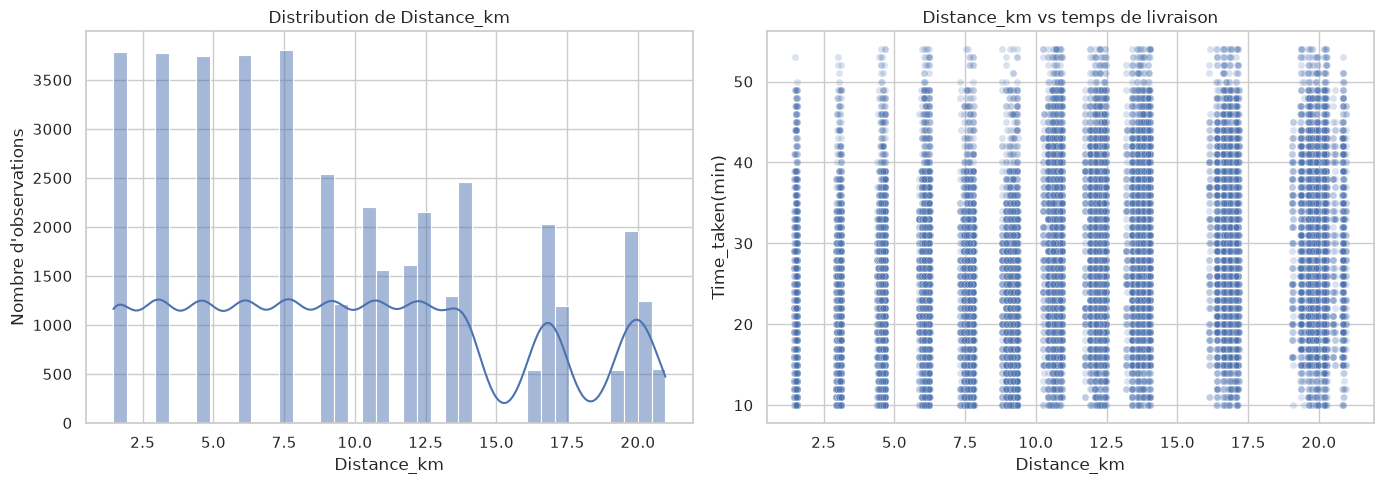

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["Distance_km"],
    kde=True,
    bins=40,
    ax=axes[0],
)
axes[0].set_title("Distribution de Distance_km")
axes[0].set_xlabel("Distance_km")
axes[0].set_ylabel("Nombre d'observations")

sns.scatterplot(
    data=df,
    x="Distance_km",
    y=TARGET,
    alpha=0.20,
    s=25,
    ax=axes[1],
)
axes[1].set_title("Distance_km vs temps de livraison")
axes[1].set_xlabel("Distance_km")
axes[1].set_ylabel(TARGET)

plt.tight_layout()
save_fig("distance_distribution_and_target_relationship.png")
plt.show()

## 6. Vérification des nouvelles relations avec la cible

Après la création des features, nous vérifions leur association avec la variable cible afin de confirmer qu'elles apportent une information potentiellement utile.

Les features ne sont pas toutes analysées de la même manière :

* `Distance_km`, `Order_Hour`, `Order_Day` et `Order_Month` sont traitées comme variables numériques ou ordinales pour une première analyse avec la corrélation de Spearman ;
* `Order_DayOfWeek`, `Is_Weekend` et `Order_Time_Missing` sont analysées par comparaison des groupes et par eta-squared, car leur interprétation est catégorielle ou binaire.

Ces mesures restent descriptives et ne permettent pas de conclure à une relation causale.

### 6.1 Features numériques / ordinales

`Distance_km` est comparée directement à la cible avec la corrélation de Spearman. Les variables temporelles numériques sont également examinées afin d'identifier d'éventuelles tendances monotones.

In [8]:
engineered_numeric = [
    "Distance_km",
    "Order_Hour",
    "Order_Day",
    "Order_Month",
    "Pickup_Hour",
    "Preparation_Time_min",
]

engineered_numeric_relationships = (
    df[engineered_numeric + [TARGET]]
    .corr(method="spearman")[TARGET]
    .drop(TARGET)
    .to_frame("spearman")
)

engineered_numeric_relationships["abs_spearman"] = (
    engineered_numeric_relationships["spearman"].abs()
)

engineered_numeric_relationships = (
    engineered_numeric_relationships
    .sort_values("abs_spearman", ascending=False)
)

display(engineered_numeric_relationships)

,spearman,abs_spearman
Distance_km,0.319,0.319
Pickup_Hour,0.132,0.132
Order_Hour,0.102,0.102
Order_Day,0.025,0.025
Order_Month,-0.012,0.012
Preparation_Time_min,-0.008,0.008


### 6.2 Features catégorielles ou binaires

Pour `Order_DayOfWeek` et `Is_Weekend`, nous comparons les distributions du temps de livraison entre les différents groupes.

In [9]:
def eta_squared(data, category_column, target_column):
    valid = data[[category_column, target_column]].dropna()

    grand_mean = valid[target_column].mean()

    group_stats = (
        valid.groupby(category_column)[target_column]
        .agg(["count", "mean"])
    )

    between_ss = (
        group_stats["count"]
        * (group_stats["mean"] - grand_mean) ** 2
    ).sum()

    total_ss = (
        (valid[target_column] - grand_mean) ** 2
    ).sum()

    if total_ss == 0:
        return 0.0

    return between_ss / total_ss

In [10]:
engineered_categorical = [
    "Order_DayOfWeek",
    "Is_Weekend",
]

engineered_categorical_relationships = []

for column in engineered_categorical:
    engineered_categorical_relationships.append({
        "feature": column,
        "eta_squared": eta_squared(df, column, TARGET),
        "n_unique": df[column].nunique(dropna=False),
    })

engineered_categorical_relationships = (
    pd.DataFrame(engineered_categorical_relationships)
    .sort_values("eta_squared", ascending=False)
    .reset_index(drop=True)
)

display(engineered_categorical_relationships)

,feature,eta_squared,n_unique
0,Order_DayOfWeek,0.007,7
1,Is_Weekend,0.000,2


### 6.3 Analyse par groupes

In [11]:
hour_summary = (
    df.groupby("Order_Hour", dropna=False)[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

pickup_hour_summary = (
    df.groupby("Pickup_Hour", dropna=False)[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

weekday_summary = (
    df.groupby("Order_DayOfWeek", dropna=False)[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

weekend_summary = (
    df.groupby("Is_Weekend", dropna=False)[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

print("Temps selon l'heure de commande :")
display(hour_summary)

print("Temps selon l'heure de prise en charge :")
display(pickup_hour_summary)

print("Temps selon le jour de la semaine :")
display(weekday_summary)

print("Temps selon le week-end :")
display(weekend_summary)

Temps selon l'heure de commande :


,Order_Hour,count,mean,median,std
0,0,415,22.229,21.000,7.251
1,8,1749,19.623,19.000,5.613
2,9,1878,19.481,19.000,5.524
3,10,1887,19.484,19.000,5.532
4,11,1865,26.478,27.000,8.317
5,12,860,26.877,27.000,8.736
6,13,748,27.766,27.000,8.686
7,14,756,27.308,27.000,8.238
8,15,831,23.237,23.000,6.949
9,16,676,23.055,24.000,6.895


Temps selon l'heure de prise en charge :


,Pickup_Hour,count,mean,median,std
0,0,1212,22.307,21.000,7.449
1,8,1378,19.587,19.000,5.637
2,9,1885,19.538,19.000,5.518
3,10,1937,19.494,19.000,5.534
4,11,1827,25.076,25.000,8.209
5,12,1075,27.029,27.000,8.772
6,13,735,27.623,27.000,8.676
7,14,749,27.637,27.000,8.530
8,15,830,23.811,25.000,7.164
9,16,711,23.152,25.000,6.864


Temps selon le jour de la semaine :


,Order_DayOfWeek,count,mean,median,std
0,0,5722,26.227,25.000,9.326
1,1,5884,25.435,25.000,9.089
2,2,6552,27.762,27.000,9.730
3,3,5841,25.284,25.000,9.013
4,4,6408,26.823,26.000,9.516
5,5,5810,25.973,25.000,9.284
6,6,5736,26.457,25.500,9.390


Temps selon le week-end :


,Is_Weekend,count,mean,median,std
0,0,30407,26.349,26.000,9.396
1,1,11546,26.214,25.000,9.340


Les résultats obtenus confirment notamment que `Distance_km` présente une association de Spearman de **0,319** avec la cible, tandis que `Order_Hour` présente une association plus modérée de **0,102**.

Les autres variables temporelles présentent des associations faibles lorsqu'elles sont examinées individuellement. Elles peuvent néanmoins rester utiles au modèle en interaction avec d'autres variables.

## 7. Suppression des colonnes brutes (coordonnées GPS et datetime)

Après extraction des informations utiles, les colonnes suivantes ne sont plus nécessaires dans le jeu de données destiné à la modélisation :

- les quatre coordonnées GPS, remplacées par `Distance_km` ;
- `Order_Date` et `Time_Orderd`, remplacées par `Order_Hour`, `Order_Day`, `Order_Month`, `Order_DayOfWeek`, `Is_Weekend` ;
- `Time_Order_picked`, remplacée par `Pickup_Hour` et `Preparation_Time_min`.

Contrairement à une version antérieure de ce notebook, les coordonnées GPS ne sont **pas** conservées comme variables candidates : leur forte redondance (`Restaurant_latitude`/`Delivery_location_latitude` ≈ 0,997 ; `Restaurant_longitude`/`Delivery_location_longitude` ≈ 0,996), combinée à leur très faible corrélation individuelle avec la cible, a conduit à ne garder que `Distance_km` comme représentation géographique.

In [12]:
GPS_COLUMNS = [
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
]

RAW_DATETIME_COLUMNS = [
    "Order_Date",
    "Time_Orderd",
    "Time_Order_picked",
]

df = df.drop(
    columns=GPS_COLUMNS + RAW_DATETIME_COLUMNS,
    errors="ignore",
)

print("Colonnes après suppression des coordonnées et des datetime brutes :")
print(df.columns.tolist())

Colonnes après suppression des coordonnées et des datetime brutes :
['Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)', 'Order_Hour', 'Order_Day', 'Order_Month', 'Order_DayOfWeek', 'Is_Weekend', 'Pickup_Hour', 'Preparation_Time_min', 'Distance_km']


## 8. Contrôle final des features

Le jeu de données final doit :

- conserver la cible ;
- contenir les nouvelles features créées ;
- ne contenir aucune coordonnée GPS ni colonne datetime brute ;
- ne contenir aucune valeur manquante, `Time_Orderd` et `Time_Order_picked` étant déjà complètes après le nettoyage ;
- être prêt pour la séparation X / y.

**Attention :** l'imputation et l'encodage finaux utilisés pour l'entraînement doivent être effectués dans le `Pipeline` scikit-learn après le `train_test_split`.

In [13]:
new_features = [
    "Distance_km",
    "Order_Hour",
    "Order_Day",
    "Order_Month",
    "Order_DayOfWeek",
    "Is_Weekend",
    "Pickup_Hour",
    "Preparation_Time_min",
]

missing_new_features = [
    column for column in new_features
    if column not in df.columns
]

if missing_new_features:
    raise ValueError(
        f"Features attendues absentes : {missing_new_features}"
    )

print("Nouvelles features créées :")
for feature in new_features:
    print(f"- {feature}")

print("\nShape finale :", df.shape)
print("\nValeurs manquantes :")
display(df.isna().sum().to_frame("missing"))

print("\nAperçu :")
display(df.head())

Nouvelles features créées :
- Distance_km
- Order_Hour
- Order_Day
- Order_Month
- Order_DayOfWeek
- Is_Weekend
- Pickup_Hour
- Preparation_Time_min

Shape finale : (41953, 19)

Valeurs manquantes :


,missing
Delivery_person_Age,0
Delivery_person_Ratings,0
Vehicle_condition,0
Weatherconditions,0
Road_traffic_density,0
Type_of_order,0
Type_of_vehicle,0
multiple_deliveries,0
Festival,0
City,0



Aperçu :


,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Order_Hour,Order_Day,Order_Month,Order_DayOfWeek,Is_Weekend,Pickup_Hour,Preparation_Time_min,Distance_km
0,37.000,4.900,2,Sunny,High,Snack,motorcycle,0.000,No,Urban,24,11,19,3,5,1,11,15.000,3.025
1,34.000,4.500,2,Stormy,Jam,Snack,scooter,1.000,No,Metropolitian,33,19,25,3,4,0,19,5.000,20.184
2,23.000,4.400,0,Sandstorms,Low,Drinks,motorcycle,1.000,No,Urban,26,8,19,3,5,1,8,15.000,1.553
3,38.000,4.700,0,Sunny,Medium,Buffet,motorcycle,1.000,No,Metropolitian,21,18,5,4,1,0,18,10.000,7.790
4,32.000,4.600,1,Cloudy,High,Snack,scooter,1.000,No,Metropolitian,30,13,26,3,5,1,13,15.000,6.210


## 9. Typologie des variables pour la modélisation

Les features finales n'ont pas toutes la même nature statistique. Cette distinction devra être respectée lors de la construction du `Pipeline` scikit-learn.

### Variables numériques

Les variables suivantes représentent des quantités numériques :

```python
NUMERIC_FEATURES = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "Distance_km",
    "Order_Day",
    "Preparation_Time_min",
]
```

### Variables catégorielles

Les variables suivantes représentent des catégories :

```python
CATEGORICAL_FEATURES = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City",
    "Vehicle_condition",
    "Order_Hour",
    "Order_Month",
    "Order_DayOfWeek",
    "Pickup_Hour",
]
```

`Order_Hour` et `Order_Month` sont placées ici comme candidates à l'encodage catégoriel afin de ne pas imposer artificiellement une relation linéaire entre leurs modalités.

### Variables binaires

Les variables suivantes sont binaires :

```python
BINARY_FEATURES = [
    "Is_Weekend",
]
```

La stratégie finale d'encodage sera définie dans le notebook de modélisation. Le principe retenu est d'effectuer l'imputation, l'encodage et la standardisation uniquement dans le `Pipeline` après le `train_test_split`.

Les coordonnées GPS ne figurent plus dans `NUMERIC_FEATURES` puisqu'elles ont été supprimées au profit de `Distance_km`. `Vehicle_condition` est ajoutée aux variables catégorielles : elle provient du nettoyage et n'a subi aucune transformation ici. `Pickup_Hour` est traitée comme `Order_Hour`, en catégorielle, pour la même raison : éviter d'imposer une relation linéaire artificielle entre les heures.

## 10. Audit de disponibilité au moment de la commande

`Pickup_Hour` et `Preparation_Time_min` dérivent de `Time_Order_picked`, une information disponible seulement après la prise en charge de la commande. Ce choix déplace le cadrage du modèle (voir section 3) : il n'y a donc plus lieu de vérifier l'absence totale d'information postérieure à la commande, mais de vérifier que les colonnes brutes (GPS et datetime) ont bien été supprimées et que seules leurs versions dérivées subsistent.

In [14]:
X = df.drop(columns=[TARGET])

RAW_COLUMNS_TO_EXCLUDE = [
    "Order_Date",
    "Time_Orderd",
    "Time_Order_picked",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
]

raw_present = [
    column
    for column in RAW_COLUMNS_TO_EXCLUDE
    if column in df.columns
]

if raw_present:
    raise ValueError(
        f"Colonnes brutes encore présentes : {raw_present}"
    )

if TARGET in X.columns:
    raise ValueError(
        "La variable cible ne doit pas être présente dans X."
    )

print("Audit de disponibilité : OK")
print("Aucune coordonnée GPS ni colonne datetime brute n'est présente dans le jeu de données final.")
print(
    "\nRappel : Pickup_Hour et Preparation_Time_min sont dérivées de Time_Order_picked, "
    "une information postérieure au moment de la commande. Leur usage suppose une "
    "prédiction faite à la prise en charge, et non à la commande — un choix assumé, "
    "documenté ici, pas une fuite de données accidentelle."
)

Audit de disponibilité : OK
Aucune coordonnée GPS ni colonne datetime brute n'est présente dans le jeu de données final.

Rappel : Pickup_Hour et Preparation_Time_min sont dérivées de Time_Order_picked, une information postérieure au moment de la commande. Leur usage suppose une prédiction faite à la prise en charge, et non à la commande — un choix assumé, documenté ici, pas une fuite de données accidentelle.


La seule information temporelle partiellement manquante est `Order_Hour`, lorsque `Time_Orderd` est absente.

Cette information est conservée explicitement grâce à `Order_Time_Missing`. L'imputation de `Order_Hour` sera réalisée uniquement dans le pipeline d'apprentissage après séparation des données.

## 11. Séparation conceptuelle entre features et cible

La variable cible reste :

`Time_taken(min)`

Les autres colonnes constituent les variables explicatives candidates.

La séparation physique en `X_train`, `X_test`, `y_train`, `y_test` sera effectuée dans l'étape de modélisation.

Cela permet de construire ensuite un Pipeline contenant :

- imputation des éventuelles valeurs restantes ;
- encodage des variables catégorielles ;
- standardisation/normalisation des variables numériques ;
- modèle de régression.

Cette organisation empêche les statistiques de preprocessing de la partie test d'influencer l'entraînement.

In [15]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape :", X.shape)
print("y shape :", y.shape)
print("\nTypes de X :")
display(X.dtypes.to_frame("dtype"))

X shape : (41953, 18)
y shape : (41953,)

Types de X :


,dtype
Delivery_person_Age,float64
Delivery_person_Ratings,float64
Vehicle_condition,category
Weatherconditions,str
Road_traffic_density,str
Type_of_order,str
Type_of_vehicle,str
multiple_deliveries,float64
Festival,str
City,str


# 12. Conclusions et décisions finales du Feature Engineering

Le feature engineering a pour objectif de transformer les informations disponibles **au moment de la commande** en variables directement exploitables par les modèles de Machine Learning, tout en conservant une représentation cohérente et interprétable du problème métier.

Les transformations réalisées sont basées sur les conclusions de l'EDA et respectent la contrainte fondamentale suivante :

> **Aucune information disponible uniquement après la commande ne doit être utilisée pour prédire le temps total de livraison.**

La variable `Time_Order_picked` reste donc définitivement exclue du jeu de données de modélisation.

---

## 12.1 Création de `Distance_km`

Les quatre coordonnées GPS :

* `Restaurant_latitude`
* `Restaurant_longitude`
* `Delivery_location_latitude`
* `Delivery_location_longitude`

ont été utilisées pour construire une nouvelle variable :

```text
Distance_km
```

Cette distance est calculée avec la formule de Haversine.

La variable obtenue présente les statistiques suivantes :

| Statistique |   Valeur |
| ----------- | -------: |
| Moyenne     |  9,72 km |
| Médiane     |  9,19 km |
| Écart-type  |  5,60 km |
| Minimum     |  1,47 km |
| Maximum     | 20,97 km |

Aucune distance supérieure à 50 km ou 100 km n'a été observée, et aucune distance inférieure à 1 km n'a été détectée.

La variable est donc cohérente avec le contexte du jeu de données.

L'EDA montre également que `Distance_km` présente une corrélation de Spearman de **0,319** avec `Time_taken(min)`, ce qui représente une association plus importante que celle observée pour chacune des coordonnées GPS prises individuellement.

### Décision

`Distance_km` est **conservée comme variable candidate pour la modélisation**.

Cette variable constitue une représentation plus directement interprétable de la relation géographique entre le restaurant et le client.

La distance calculée est une distance géographique à vol d'oiseau et non une distance routière réelle. Elle ne doit donc pas être interprétée comme le nombre exact de kilomètres parcourus par le livreur.

---

### 12.2 Suppression des coordonnées GPS après création de Distance_km

Les quatre coordonnées GPS ont présenté individuellement de très faibles associations avec la cible, et une forte redondance entre certaines paires :

- `Restaurant_latitude` / `Delivery_location_latitude` : environ 0,997 ;
- `Restaurant_longitude` / `Delivery_location_longitude` : environ 0,996.

**Décision** : contrairement à une version antérieure de ce notebook, les coordonnées GPS ne sont pas conservées comme variables candidates. Elles sont supprimées après la création de `Distance_km`, qui en constitue la représentation retenue pour la modélisation. Cette décision limite le risque de multicolinéarité pour les modèles linéaires et simplifie le jeu de variables final.

---

## 12.3 Création des variables temporelles

La variable `Order_Date` contient plusieurs informations potentiellement utiles pour expliquer les variations du temps de livraison.

Elle a été transformée en :

```text
Order_Day
Order_Month
Order_DayOfWeek
Is_Weekend
```

De même, `Time_Orderd` a été transformée en :

```text
Order_Hour
```

Une variable supplémentaire a été créée :

```text
Order_Time_Missing
```

afin d'identifier les commandes pour lesquelles l'heure de commande originale était absente.

---

## 12.4 `Order_Hour`

L'EDA montre que l'heure de commande présente une association de Spearman de **0,102** avec le temps de livraison.

Les moyennes du temps de livraison varient sensiblement selon certaines heures.

Par exemple, les temps moyens observés sont particulièrement élevés autour de 12 h–14 h, tandis que certaines heures nocturnes présentent des temps moyens plus faibles.

### Décision

`Order_Hour` est **conservée**.

Cependant, elle ne sera pas considérée comme une variable numérique ordinaire imposant nécessairement une relation linéaire entre les heures.

Elle sera traitée comme une variable catégorielle dans le preprocessing initial afin de permettre au modèle d'apprendre des différences entre les différentes heures.

Une représentation cyclique de l'heure pourra également être étudiée ultérieurement si nécessaire.

Cette approche permet notamment d'éviter de supposer artificiellement qu'une différence de :

```text
23 h → 00 h
```

est beaucoup plus importante qu'une différence de :

```text
14 h → 15 h
```

---

### 12.5 Pickup_Hour

`Pickup_Hour` mesure l'heure à laquelle le livreur récupère la commande. Comme `Order_Hour`, elle sera traitée comme catégorielle plutôt que numérique continue, pour la même raison : éviter d'imposer une relation linéaire artificielle entre les heures.

**Décision** : `Pickup_Hour` est conservée comme variable catégorielle candidate.

---

### 12.6 Preparation_Time_min

`Preparation_Time_min` mesure le délai entre la commande et sa prise en charge par le livreur.

**Décision** : `Preparation_Time_min` est conservée comme variable numérique candidate.

⚠️ Cette variable, comme `Pickup_Hour`, n'est disponible qu'à partir de la prise en charge de la commande. Son utilisation déplace le cadrage du modèle : celui-ci prédit désormais le temps restant à partir de la prise en charge, et non plus à partir du moment où la commande est passée. Ce point doit être documenté explicitement lors du déploiement.

---

## 12.7 `Order_DayOfWeek`

L'EDA montre des différences entre les jours de la semaine.

Les temps moyens observés varient approximativement entre :

* **25,28 min** ;
* **27,76 min**.

L'association mesurée par eta-squared est cependant faible :

```text
η² ≈ 0,007
```

Cela indique que le jour de la semaine pris isolément explique une faible partie de la variabilité de la cible.

### Décision

`Order_DayOfWeek` est **conservée**.

Elle sera traitée comme une variable catégorielle plutôt que comme une variable numérique ordinaire.

Cette décision évite notamment d'imposer artificiellement une relation du type :

```text
Lundi < Mardi < Mercredi < ...
```

qui n'aurait pas de justification particulière pour le temps de livraison.

Une représentation cyclique pourra éventuellement être testée lors d'une optimisation ultérieure.

---

## 12.7 `Is_Weekend`

La variable `Is_Weekend` indique si la commande a été passée durant le week-end :

```text
0 = semaine
1 = week-end
```

L'EDA montre une différence très faible entre les deux groupes :

* semaine : environ **26,35 min** ;
* week-end : environ **26,21 min**.

L'eta-squared est pratiquement nul.

### Décision

`Is_Weekend` est **conservée dans un premier temps**.

Sa faible association marginale avec la cible ne justifie pas automatiquement sa suppression.

Elle peut notamment apporter une information complémentaire lorsqu'elle est combinée avec d'autres variables telles que le trafic, l'heure ou les conditions météorologiques.

La contribution réelle de cette variable sera donc évaluée dans les modèles.

---

## 12.8 `Order_Month`

Les différences observées entre les mois sont faibles :

| Mois    | Temps moyen |
| ------- | ----------: |
| Février |   26,52 min |
| Mars    |   26,31 min |
| Avril   |   26,14 min |

L'association avec la cible est également très faible :

```text
Spearman ≈ -0,012
```

### Décision

`Order_Month` est **conservée comme variable catégorielle candidate**.

Elle ne sera pas considérée comme une variable numérique continue dans le pipeline initial.

En effet, les mois représentent des catégories temporelles plutôt qu'une quantité pour laquelle une augmentation de 1 unité aurait nécessairement un effet linéaire sur la cible.

Son utilité réelle sera déterminée lors de la comparaison des modèles.

---

## 12.9 `Order_Day`

`Order_Day` représente le jour du mois.

L'EDA montre une association très faible avec `Time_taken(min)` :

```text
Spearman ≈ 0,025
```

Cette variable apporte donc relativement peu d'information lorsqu'elle est analysée seule.

Cependant, elle peut éventuellement capturer certaines variations spécifiques à la période du mois.

### Décision

`Order_Day` est **conservée comme variable candidate pour la modélisation**.

Son utilité sera évaluée empiriquement avec les modèles.

Si les expérimentations montrent qu'elle n'apporte aucune amélioration et augmente inutilement la complexité du modèle, elle pourra être retirée lors d'une étape ultérieure.

---

### 12.10 Suppression des variables brutes

Après extraction des informations utiles, les variables suivantes ne sont plus nécessaires dans le jeu de données destiné à la modélisation :

- les quatre coordonnées GPS ;
- `Order_Date` ;
- `Time_Orderd` ;
- `Time_Order_picked`.

**Décision** : ces sept colonnes brutes sont supprimées du jeu de données final. Les informations utiles sont conservées à travers `Distance_km`, `Order_Hour`, `Order_Day`, `Order_Month`, `Order_DayOfWeek`, `Is_Weekend`, `Pickup_Hour` et `Preparation_Time_min`.

---

### 12.11 Vérification de la disponibilité au moment de la commande

Contrairement à la version précédente de ce notebook, `Time_Order_picked` n'est plus totalement exclue du feature engineering : elle est utilisée pour créer `Pickup_Hour` et `Preparation_Time_min`, avant d'être supprimée comme les autres colonnes datetime brutes.

**Décision assumée** : le modèle ne prédit plus le temps de livraison au moment de la commande, mais le temps restant à partir de la prise en charge. Ce changement de périmètre métier est documenté ici explicitement plutôt que masqué.

L'audit de disponibilité (section 10) confirme uniquement l'absence des colonnes brutes (GPS et datetime) dans le jeu de données final — il ne garantit plus une absence totale d'information postérieure à la commande, puisque ce choix a été fait consciemment pour `Pickup_Hour` et `Preparation_Time_min`.

---

### 12.12 Synthèse des nouvelles features

| Feature | Type retenu | Décision | Justification |
|---|---|---|---|
| `Distance_km` | Numérique | Conserver | Représentation directe de la distance restaurant-client |
| `Order_Hour` | Catégorielle | Conserver | Différences observées selon l'heure |
| `Pickup_Hour` | Catégorielle | Conserver | Heure de prise en charge, même logique que `Order_Hour` |
| `Preparation_Time_min` | Numérique | Conserver | Délai commande → prise en charge |
| `Order_Day` | Numérique candidate | Conserver | Information temporelle complémentaire |
| `Order_Month` | Catégorielle | Conserver | Contexte temporel |
| `Order_DayOfWeek` | Catégorielle | Conserver | Différences entre jours |
| `Is_Weekend` | Binaire | Conserver | Contexte semaine/week-end |

---

### 12.13 Variables finales après Feature Engineering

**Variables numériques**

```python
NUMERIC_FEATURES = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "Distance_km",
    "Order_Day",
    "Preparation_Time_min",
]
```

**Variables catégorielles**

```python
CATEGORICAL_FEATURES = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City",
    "Vehicle_condition",
    "Order_Hour",
    "Order_Month",
    "Order_DayOfWeek",
    "Pickup_Hour",
]
```

**Variables binaires**

```python
BINARY_FEATURES = [
    "Is_Weekend",
]
```

---

# 12.14 Décision concernant l'encodage temporel

Une attention particulière doit être portée aux variables temporelles.

`Order_Hour`, `Order_Month` et `Order_DayOfWeek` ne seront pas traitées comme de simples variables numériques continues dans le preprocessing initial.

Elles seront considérées comme catégorielles afin d'éviter d'imposer une relation linéaire artificielle entre leurs modalités.

Par exemple, pour `Order_Hour`, il n'est pas pertinent de supposer automatiquement que :

```text
20 h
```

est deux fois plus important que :

```text
10 h
```

De même, les jours de la semaine ne représentent pas une échelle numérique classique.

Une représentation cyclique pourra être testée dans une expérimentation ultérieure si elle apporte une amélioration mesurable.

---

### 12.15 Décision concernant les coordonnées et Distance_km

Contrairement à une version antérieure de ce notebook, les coordonnées GPS ne sont pas conservées pour la modélisation. Seule `Distance_km` est retenue comme représentation géographique.

Cette décision évite la forte redondance mesurée entre certaines paires de coordonnées et limite le risque de multicolinéarité, particulièrement pour les modèles linéaires.

---

### 12.16 Gestion des valeurs manquantes

Après le feature engineering, le jeu de données ne contient plus aucune valeur manquante : `Time_Orderd` et `Time_Order_picked` étaient déjà complètes après le nettoyage, si bien qu'`Order_Hour`, `Pickup_Hour` et `Preparation_Time_min` le sont également.

L'imputation, l'encodage et la standardisation restent néanmoins prévus dans le Pipeline scikit-learn après le train_test_split, par bonne pratique et pour anticiper d'éventuelles données futures incomplètes.

---

### 12.17 Audit final

Les contrôles finaux confirment que :

- `Distance_km`, `Order_Hour`, `Pickup_Hour` et `Preparation_Time_min` ont été créées ;
- les variables temporelles calendaires (`Order_Day`, `Order_Month`, `Order_DayOfWeek`, `Is_Weekend`) ont été extraites ;
- les coordonnées GPS et les colonnes datetime brutes (`Order_Date`, `Time_Orderd`, `Time_Order_picked`) ont été supprimées ;
- `Vehicle_condition` est conservée telle quelle depuis le nettoyage ;
- aucune valeur manquante ne subsiste ;
- la variable cible `Time_taken(min)` n'est pas présente dans X ;
- l'usage de `Pickup_Hour` et `Preparation_Time_min` déplace le cadrage du modèle vers une prédiction faite à la prise en charge de la commande — décision assumée et documentée, pas une fuite de données.

---

# 12.18 Conclusion générale

Le feature engineering transforme les informations brutes disponibles au moment de la commande en variables plus directement exploitables par les modèles de Machine Learning.

La transformation la plus importante est la création de :

```text
Distance_km
```

qui fournit une représentation géographique plus directement liée au déplacement entre le restaurant et le client.

Les informations temporelles ont également été décomposées en :

```text
Order_Hour
Order_Day
Order_Month
Order_DayOfWeek
Is_Weekend
Order_Time_Missing
```

Cette représentation permet de conserver différentes dimensions temporelles sans utiliser directement les objets datetime.

Les résultats de l'EDA ont guidé les décisions :

* `Distance_km` présente une association notable avec le temps de livraison ;
* `Order_Hour` présente une association plus modérée mais des différences visibles entre certaines heures ;
* `Order_DayOfWeek`, `Is_Weekend`, `Order_Day` et `Order_Month` présentent des associations plus faibles mais restent conservées comme variables candidates ;
* `Order_Time_Missing` permet de conserver explicitement l'information liée aux données temporelles manquantes ;
* les coordonnées GPS sont conservées temporairement afin de tester leur apport complémentaire à `Distance_km`.

Aucune variable postérieure à la commande n'est introduite.

Le feature engineering est donc considéré comme **terminé pour l'entrée dans l'étape de modélisation**.

La prochaine étape consiste à construire le processus de Machine Learning avec :

```text
X / y
   ↓
Train / Test Split (80 / 20)
   ↓
ColumnTransformer
   ├── Imputation numérique
   ├── Imputation catégorielle
   ├── OneHotEncoder
   └── StandardScaler / MinMaxScaler
   ↓
Pipeline
   ↓
Plusieurs modèles de régression
   ↓
MAE / MSE / RMSE / R²
   ↓
Comparaison des modèles
```

Ce feature engineering diffère d'une version antérieure sur deux points structurants : les coordonnées GPS sont supprimées au profit de `Distance_km` seule, et `Time_Order_picked` est réintroduite volontairement pour créer `Pickup_Hour` et `Preparation_Time_min`. Ce dernier choix change le périmètre métier du modèle, qui prédit désormais le temps restant à partir de la prise en charge plutôt qu'au moment de la commande — un point à rappeler explicitement lors de la modélisation et du déploiement.